# Temas Tratados en el Trabajo Práctico 4

* Representación del Conocimiento y Razonamiento Lógico.

* Estrategias de resolución de hipótesis: Encadenamiento hacia Adelante, Encadenamiento hacia Atrás y Resolución por Contradicción.

* Representación basada en circuitos.

## Ejercicios Teóricos

1. ¿Qué es una inferencia?

2. ¿Cómo se verifica que un modelo se infiere de la base de conocimientos?

3. Observe la siguiente base de conocimiento:

$R1: b ∧ c → a$

$R2: d ∧ e → b$

$R3: g ∧ e → b$

$R4: e → c$

$R5: d$

$R6: e$

$R7: a ∧ g → f$

        3.1 ¿Cómo se puede probar que $a = True$ a través del encadenamiento hacia adelante? Este método solamente usa reglas ya incorporadas a la base de conocimiento para inferir la hipótesis, ¿qué propiedad debe tener el algoritmo para asegurar que esta inferencia sea posible?

        3.2 ¿Cómo se puede probar que $a = True$ a través del encadenamiento hacia atrás? Este método asigna un valor de verdad a la hipótesis y deriva las sentencias de la base de conocimiento, ¿qué propiedad debe tener el algoritmo para asegurar que esta derivación sea posible?

        3.3 Exprese la base de conocimiento en su Forma Normal Conjuntiva. A continuación, demuestre por contradicción que $a = True$.

4. Diseñe con lógica proposicional basada en circuitos las proposiciones *OrientadoDerecha* y *Agente ubicado en la casilla [1,2]* para el mundo de wumpus de 4x4. Dibuje el circuito correspondiente.


5. El nonograma es un juego en el cual se posee un tablero en blanco y cada fila y columna presenta información sobre la longitud de un bloque en dicha fila/columna. Además, la leyenda puede indicar más de un número, indicando esto que existen varios bloques de las longitudes mostradas por la leyenda y en el mismo orden, separados por al menos un espacio vacío.

Resuelva el nonograma de la imagen de abajo escribiendo en primer lugar cada regla que puede incorporarse a la base de conocimientos inicial e incorporando cada inferencia que realice.

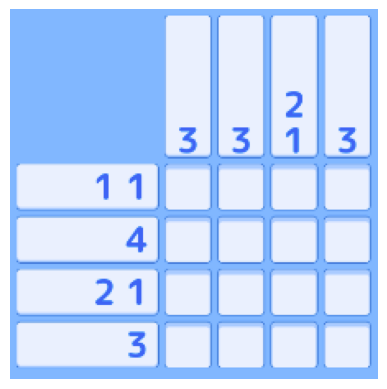

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1SKiXvrI_TX-U4sbw60TYSRmaNYyFixmI"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

6. Implementar un motor de inferencia con encadenamiento hacia adelante. Pruébelo con las proposiciones del ejercicio 3.

In [1]:
def forward_chaining():
    # Base de conocimiento: antecedentes -> consecuente
    reglas = [
        {"nombre": "R1", "antecedentes": ["b", "c"], "consecuente": "a"},
        {"nombre": "R2", "antecedentes": ["d", "e"], "consecuente": "b"},
        {"nombre": "R3", "antecedentes": ["g", "e"], "consecuente": "b"},
        {"nombre": "R4", "antecedentes": ["e"], "consecuente": "c"},
        {"nombre": "R7", "antecedentes": ["a", "g"], "consecuente": "f"},
    ]

    # Hechos iniciales (R5 y R6)
    hechos = {"d", "e"}
    reglas_aplicadas = set()
    objetivo = "a"

    print(f"Hechos iniciales: {sorted(list(hechos))}")
    print("Iniciando proceso de inferencia:\n")

    cambio = True
    while cambio:
        cambio = False
        for regla in reglas:
            nombre = regla["nombre"]
            antecedentes = regla["antecedentes"]
            consecuente = regla["consecuente"]

            # Verificar si la regla no fue aplicada y si todos sus antecedentes son verdaderos
            if nombre not in reglas_aplicadas:
                if all(antecedente in hechos for antecedente in antecedentes):
                    reglas_aplicadas.add(nombre)
                    if consecuente not in hechos:
                        hechos.add(consecuente)
                        cambio = True
                        print(f"Se aplica {nombre}: antecedentes {antecedentes} son verdaderos -> Nuevo hecho: {consecuente}")
                    else:
                        print(f"Se aplica {nombre}: el consecuente '{consecuente}' ya era conocido.")

    print(f"\nConjunto final de hechos: {sorted(list(hechos))}")
    
    # Verificación del objetivo
    if objetivo in hechos:
        print(f"Resultado: Se demostró con éxito que {objetivo} = True.")
    else:
        print(f"Resultado: No se pudo demostrar que {objetivo} = True.")

if __name__ == "__main__":
    forward_chaining()

Hechos iniciales: ['d', 'e']
Iniciando proceso de inferencia:

Se aplica R2: antecedentes ['d', 'e'] son verdaderos -> Nuevo hecho: b
Se aplica R4: antecedentes ['e'] son verdaderos -> Nuevo hecho: c
Se aplica R1: antecedentes ['b', 'c'] son verdaderos -> Nuevo hecho: a

Conjunto final de hechos: ['a', 'b', 'c', 'd', 'e']
Resultado: Se demostró con éxito que a = True.


Prompt utlizado:
"Sos un ingeniero en programación con experiencia en Inteligencia Artificial, lógica proposicional y sistemas basados en conocimiento. Necesitas resolver un ejercicio académico creando un motor de inferencia por encadenamiento hacia adelante en Python, de manera simple, clara y didáctica.

La base de conocimiento es:

R1: b ∧ c → a
R2: d ∧ e → b
R3: g ∧ e → b
R4: e → c
R5: d
R6: e
R7: a ∧ g → f

Los hechos iniciales son d=True y e=True.
No podes usar librerías externas de IA, utiliza un ciclo que aplique repetidamente las reglas cuyos antecedentes sean verdaderos, agregando los nuevos hechos obtenidos, hasta que ya no sea posible realizar nuevas inferencias.
El programa debe mostrar qué reglas se aplican y finalmente indicar si se pudo demostrar que a=True."

7. Implementar un motor de inferencia con encadenamiento hacia atrás. Pruébelo con las proposiciones del ejercicio 3.

propmt utilizado: 
Actúa como un Ingeniero de Software experto en Inteligencia Artificial y Sistemas Basados en Conocimiento. Necesito que diseñes e implementes en Python un Motor de Inferencia por Encadenamiento hacia Atrás (Backward Chaining) para lógica proposicional (cláusulas de Horn), basándote en la teoría de Russell & Norvig.

---

### 1. ALGORITMO TEÓRICO A IMPLEMENTAR
El motor de inferencia debe utilizar un algoritmo recursivo de búsqueda en profundidad (DFS) para demostrar una hipótesis o consulta (Query) "q":

* **Fatos Base (Hechos):** Si "q" pertenece al conjunto de hechos conocidos inicialmente, retornar `True`.
* **Detección de Bucles Infinitos:** Para evitar bucles infinitos causados por reglas circulares (como P => Q y Q => P), el algoritmo debe mantener un conjunto local de símbolos actualmente en proceso de evaluación en la rama recursiva (pila de llamadas). Si "q" ya se encuentra en este conjunto "en progreso", debe abortar la rama y retornar `False`.
* **Evaluación de Reglas:** Si "q" no es un hecho, identificar todas las reglas en la Base de Conocimiento (BC) cuya conclusión (consecuente) sea "q". 
  * Para cada una de estas reglas, intentar demostrar de forma recursiva (hacia atrás) todos y cada uno de los antecedentes (premisas).
  * Si TODOS los antecedentes de al menos una regla son exitosamente demostrados (`True`), entonces "q" es verdadero.
  * Añadir "q" a la tabla de hechos conocidos (Memorización/Caching) para no tener que volver a computar su árbol de pruebas si se requiere en otra rama. Retornar `True`.
* Si ninguna regla logra demostrar "q", retornar `False`.

---

### 2. REQUISITOS DEL CÓDIGO
* **Lenguaje:** Python puro (sin dependencias de librerías lógicas externas como `sympy` o `prolog`).
* **Estructura Modular:** Diseña una clase `MotorInferenciaAtras` que reciba la Base de Conocimiento (reglas e inicialmente hechos) en su constructor.
* **Representación de la BC:**
  * **Reglas:** Estructuras que contengan una lista de premisas (antecedentes) y una conclusión (consecuente). Por ejemplo: `{'premisas': ['b', 'c'], 'conclusion': 'a'}` para representar `b ∧ c => a`.
  * **Hechos:** Un conjunto (`set`) de símbolos proposicionales que son verdaderos inicialmente.

---

### 3. TRAZA DE EJECUCIÓN DETALLADA (CLAVE ACADÉMICA)
El motor de inferencia debe imprimir por consola una traza legible y sangrada (usando tabuladores según el nivel de profundidad recursiva) que muestre cada paso de la deducción:
* Cuál es el objetivo (Goal) actual que se intenta demostrar.
* Si el objetivo ya se resolvió porque es un hecho inicial o está en el caché de memorización.
* Si se detectó un ciclo infinito abortando esa rama.
* Cuál regla se seleccionó para intentar demostrar el objetivo y qué sub-objetivos (antecedentes) se dispararon.
* El resultado de éxito o falla de cada sub-objetivo individual.
* El veredicto final para el objetivo principal de la consulta.

---

### 4. CASO DE PRUEBA OBLIGATORIO (EJERCICIO 3 DEL TP4)
El script debe configurar automáticamente la Base de Conocimiento del Ejercicio 3 para probar el motor:

**Base de Conocimiento:**
* Reglas:
  - b ∧ c => a
  - d ∧ e => b
  - g ∧ e => b
  - e => c
  - a ∧ g => f
* Hechos Iniciales:
  - d
  - e

**Consultas de Prueba obligatorias que debe realizar el script al ejecutarse:**
1. **Consulta 'a':** Debería retornar `True` (para probar 'a', busca 'b' y 'c'. Para 'b' prueba 'd' y 'e' (verdaderos). Para 'c' prueba 'e' (verdadero). Concluye 'a' exitosamente).
2. **Consulta 'f':** Debería retornar `False` (intenta probar 'f', lo que requiere 'a' y 'g'. Aunque 'a' se demuestra, 'g' no tiene reglas que lo concluyan ni es hecho inicial, por lo que falla).
3. **Consulta 'b':** Debería retornar `True` (hecho memorizado o probado previamente).

In [ ]:
Codigo utilizado: 
import sys
if hasattr(sys.stdout, "reconfigure"):
sys.stdout.reconfigure(encoding="utf-8")
class MotorInferenciaAtras:
def init(self, reglas):
self.reglas = reglas
self.hechos = set()
def _reglas_para(self, objetivo):
return [r for r in self.reglas if r['conclusion'] == objetivo]
@staticmethod
def _antecedente(regla):
return ' ∧ '.join(regla['premisas']) if regla['premisas'] else '⊤'
def prove(self, objetivo, en_progreso=None, profundidad=0):
if en_progreso is None:
en_progreso = set()
indent = "\t" * profundidad
print(f"{indent}[Nivel {profundidad}] Objetivo: '{objetivo}'")
if objetivo in self.hechos:
print(f"{indent}\t-> '{objetivo}' ya fue demostrado y está memorizado. Resultado: True")
return True
if objetivo in en_progreso:
print(f"{indent}\t-> Ciclo detectado: '{objetivo}' ya está en evaluación en esta misma rama. Abortando. Resultado: False")
return False
reglas_aplicables = self._reglas_para(objetivo)
if not reglas_aplicables:
print(f"{indent}\t-> No existe ninguna regla que concluya '{objetivo}'. Resultado: False")
return False
en_progreso.add(objetivo)
for regla in reglas_aplicables:
antecedente = self._antecedente(regla)
print(f"{indent}\tProbando {regla['id']}: {antecedente} => {regla['conclusion']}")
exito_regla = True
for premisa in regla['premisas']:
resultado = self.prove(premisa, en_progreso, profundidad + 1)
print(f"{indent}\tSub-objetivo '{premisa}' de {regla['id']} ({antecedente} => {regla['conclusion']}): {'ÉXITO' if resultado else 'FALLA'}")
if not resultado:
exito_regla = False
break
if exito_regla:
print(f"{indent}\t-> {regla['id']} satisfecha. '{objetivo}' demostrado. Se memoriza como hecho.")
self.hechos.add(objetivo)
en_progreso.discard(objetivo)
return True
print(f"{indent}\t-> {regla['id']} fallida para '{objetivo}'. Se prueba la siguiente regla (si existe).")
print(f"{indent}\t-> Ninguna regla logró demostrar '{objetivo}'. Resultado: False")
en_progreso.discard(objetivo)
return False
def consultar(self, objetivo):
print("=" * 70)
print(f"CONSULTA: ¿Se puede demostrar '{objetivo}'?")
print("-" * 70)
resultado = self.prove(objetivo)
print("-" * 70)
print(f"VEREDICTO FINAL: '{objetivo}' = {resultado}")
print("=" * 70)
print()
return resultado
if name == "main":
reglas = [
{'id': 'R1', 'premisas': ['b', 'c'], 'conclusion': 'a'},
{'id': 'R2', 'premisas': ['d', 'e'], 'conclusion': 'b'},
{'id': 'R3', 'premisas': ['g', 'e'], 'conclusion': 'b'},
{'id': 'R4', 'premisas': ['e'], 'conclusion': 'c'},
{'id': 'R5', 'premisas': [], 'conclusion': 'd'},
{'id': 'R6', 'premisas': [], 'conclusion': 'e'},
{'id': 'R7', 'premisas': ['a', 'g'], 'conclusion': 'f'},
]
motor = MotorInferenciaAtras(reglas)
print("BASE DE CONOCIMIENTO (Ejercicio 3 del TP4)")
for r in reglas:
antecedente = MotorInferenciaAtras._antecedente(r)
print(f"  {r['id']}: {antecedente} => {r['conclusion']}")
print()
resultado_a = motor.consultar('a')
resultado_f = motor.consultar('f')
resultado_b = motor.consultar('b')
print("RESUMEN DE RESULTADOS")
print(f"  Consulta 'a' -> {resultado_a}  (esperado: True)")
print(f"  Consulta 'f' -> {resultado_f}  (esperado: False)")
print(f"  Consulta 'b' -> {resultado_b}  (esperado: True)")

8. Implementar un motor de inferencia por contradicción que detecte si el conjunto de proposiciones del ejercicio 3 es inconsistente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)